# Pulp Brightness Prediction — Gradient Boosting Model

Predicting pulp brightness (`s1_brightness_out`) after the first ClO₂ bleaching stage at Södra's Värö mill, using a `HistGradientBoostingRegressor`. This is the best-performing of the three models compared in the project (versus linear and ridge regression).

Two hard requirements from Södra shape the modeling:

1. **Monotonicity** — predicted brightness must be non-decreasing in the chlorine-dioxide feed `s1_feed_clo2`.
2. **Importance** — `s1_feed_clo2` must rank in the top 3 features by mean |SHAP| value.

> **Note:** the production dataset and the project's private helper modules (`constants`, `functions`, `evaluation`) are proprietary to Södra and are not included in this repository, so the notebook is not directly runnable here. It is shared to document the modeling approach.

## 1. Load and preprocess the data

Load the raw sensor parquet, keep only columns measured **upstream** of the brightness sensor, shift the target by the pulp's transport delay through the reactor, and aggregate to 15-minute windows to match the brightness-measurement cadence.

In [81]:
from typing import Dict, List, Tuple
import warnings

import datetime
import importlib
from pathlib import Path
import os
import sys
from typing import Dict, List, Tuple
import warnings
# 3rd party imports
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import mlflow

# Supress warnings
warnings.filterwarnings('ignore')
root_dir = Path.cwd().parent.resolve()
data_dir = root_dir / "data"
utils_dir = root_dir / "utils"
# Append src folder to path
sys.path.append(str(utils_dir))

# Local imports
import constants
importlib.reload(sys.modules['constants'])
from constants import (
    DATA_FILE_NAME,
    MILL_NAME,
    PARQUET_EXTENSION,
    TS_COL,
)
# Import the functions
import functions
importlib.reload(sys.modules['functions'])
from functions import (
    hello_mill,
    apply_time_offset,
    aggregate_data
)
# --- Load raw production data (proprietary; not included in this repo) ---
file_path = data_dir / f"{DATA_FILE_NAME}.{PARQUET_EXTENSION}"
raw_df = pd.read_parquet(file_path)
df = raw_df.copy()
df[TS_COL] = pd.to_datetime(df[TS_COL])
df = df.set_index(TS_COL)
df = df.iloc[:, 0:49]
df.head()
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna()
# Keep only sensors measured upstream of the brightness reading, so the model
# cannot use downstream information that would not be available at prediction time
cols_to_keep = ['t7t8_brightness_out', 
                't7t8_fiber_length_out', 
                't7t8_production', 
                's1_feed_clo2', 
                's1_feed_edta', 
                't7t8_kappa_out', 
                't7t8_dilution_factor',
                's1_kappa_factor', 
                's1_level_downpipe', 
                's1_level_reactor', 
                's1_production', 
                's1_residence_time_downpipe', 
                's1_residence_time_reactor', 
                's1_temp_reactor_in', 
                's1_brightness_out']
df = df[cols_to_keep]
target_col = 's1_brightness_out'
feature_cols = [col for col in df.keys() if col!=target_col]
# Shift the target to account for the pulp's transport delay through the reactor
df = apply_time_offset(
    data=df,
    col_to_offset=target_col,
    offset_cols=["s1_residence_time_downpipe", "s1_residence_time_reactor"]
)
# Aggregate to 15-minute windows to match the cadence of the brightness sensor
df = aggregate_data(
    data=df,
    aggregation_freq = "15min",
    target_col = target_col,
    feature_cols = feature_cols
)

## 2. Add a previous-brightness feature

Brightness is autocorrelated — the pulp flows continuously, so recent brightness readings carry signal about the next one. We add `prev_out`, the average of the two previous brightness values. This has to happen **before** outlier filtering so the lag stays correctly aligned.

In [82]:
prev_out = df['s1_brightness_out'].values

# Compute the average of the last two values and shift the rest accordingly
prev_out_avg = (prev_out[1:prev_out.shape[0]-1] + prev_out[ :prev_out.shape[0]-2]) / 2

# Remove the first two rows and create the 'prev_out' column with the computed average values
df = df.iloc[2:]
df['prev_out'] = prev_out_avg


### Verify the lag feature

Quick sanity-check that `prev_out` lines up with `s1_brightness_out`.

In [73]:
df[['prev_out', 's1_brightness_out']].head()

,prev_out,s1_brightness_out
timestamp,,
2021-01-01 00:30:00,61.376952,61.461838
2021-01-01 00:45:00,61.337996,61.449081
2021-01-01 01:00:00,61.453546,61.297118
2021-01-01 01:15:00,61.350305,61.659228
2021-01-01 01:30:00,61.532490,62.257353


## 3. Filter, split, scale, and add polynomial features

Drop production-stoppage rows, split the data **chronologically** into train / validation / test, remove outliers from the training set, scale, and expand into degree-2 polynomial features.

Rows with `s1_production < 900` are production stoppages — the sensors keep logging but the values are meaningless, so we drop them.

In [83]:
df = df[df['s1_production'] >= 900]

Split **chronologically**, not randomly: the last month is the test set, the three months before it are validation, and everything earlier is training. A z-score filter (|z| > 3) then removes outliers from the **training set only**.

In [84]:
cutoff_date = '2022-02-01 00:00:00'
training_data = df.loc[:cutoff_date].iloc[:-1] # Exclude cutoff from training
testing_data = df.loc[cutoff_date:]
 
cutoff_date2 = '2021-12-01 00:00:00'
validation_data = training_data.loc[cutoff_date2:]
training_data = training_data.loc[:cutoff_date2].iloc[:-1]

print(training_data.shape)
from scipy.stats import zscore
z_scores = zscore(training_data)
abs_z_scores = np.abs(z_scores)
filtered_entries = (abs_z_scores < 3).all(axis=1)
training_data =training_data[filtered_entries]
print(training_data.shape)

(28386, 16)
(26257, 16)


Scale with `RobustScaler` (dampens any remaining outliers) followed by `StandardScaler`, then add degree-2 polynomial interaction features. All transformers are fit on the training set only, then applied to validation and test.

In [85]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import RobustScaler

y_train = training_data[target_col]
y_val = validation_data[target_col]
y_test = testing_data[target_col]
X_train = training_data.drop(columns=[target_col])
X_val = validation_data.drop(columns=[target_col])
X_test = testing_data.drop(columns=[target_col])

scaler = RobustScaler()
# Fit the scaler on the training data
scaler.fit(X_train)

# Transform both training and testing data
X_train = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_val = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
# Transform both training and testing data
X_train = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_val = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)



from sklearn.preprocessing import PolynomialFeatures

# Initialize PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)

# Fit and transform X_train
X_train_poly = poly.fit_transform(X_train)
X_train = pd.DataFrame(X_train_poly, columns=poly.get_feature_names_out(X_train.columns), index=X_train.index)

# Transform X_test and X_val using the same PolynomialFeatures instance
X_test_poly = poly.transform(X_test)
X_test = pd.DataFrame(X_test_poly, columns=poly.get_feature_names_out(X_test.columns), index=X_test.index)

X_val_poly = poly.transform(X_val)
X_val = pd.DataFrame(X_val_poly, columns=poly.get_feature_names_out(X_val.columns), index=X_val.index)


## 4. Constrained greedy feature selection

Forward-select features by validation R², with two constraints that enforce Södra's requirements:

- `s1_feed_clo2` is **pre-selected** and locked in as the first (monotonic) feature, and no other `clo2` combination may enter.
- A candidate is only eligible if `s1_feed_clo2`'s mean |SHAP| importance stays at least **50% of the top feature's** — this keeps the chemical-dosing signal from being crowded out.

The search is capped at a small number of features to keep the model simple and interpretable.

In [50]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.feature_selection import SequentialFeatureSelector
from matplotlib import pyplot as plt
import shap
import random


def get_importance(fitted_model, X_test):
    explainer = shap.TreeExplainer(fitted_model)
    shap_values = explainer.shap_values(X_test)
    feature_names = X_test.columns
    rf_resultX = pd.DataFrame(shap_values, columns=feature_names)
    
    # Compute mean absolute SHAP values
    vals = np.abs(rf_resultX.values).mean(0)
    shap_importance = pd.DataFrame(list(zip(feature_names, vals)),
                                   columns=['col_name', 'feature_importance_vals'])
    
    # Sort by importance
    shap_importance.sort_values(by='feature_importance_vals', ascending=False, inplace=True)

    top_feature_value = shap_importance['feature_importance_vals'].iloc[0]
    clo2_value = shap_importance.loc[shap_importance['col_name'] == 's1_feed_clo2', 'feature_importance_vals'].values[0]
    
    # Check if clo2 is at least 50% of the top feature
    return clo2_value >= 0.5 * top_feature_value


def forward_select(n_features):
    selected_features = ['s1_feed_clo2']
    best_scores = []
    while len(selected_features) < n_features:
        non_selected_features = [f for f in X_train.keys() if f not in selected_features]
        max_score = -100
        best_feature = None
        for feature in non_selected_features:
            if 'clo2' in feature:
                pass
            else:
                now_select = selected_features + [feature]
                constr = [0 for _ in range(len(now_select))]
                constr[0] = 1
                hb = HistGradientBoostingRegressor(random_state=400, monotonic_cst=constr)
                hb.fit(X_train[now_select], y_train)
                
                # Check SHAP importance ratio
                if get_importance(hb, X_val[now_select]):
                    score = hb.score(X_val[now_select], y_val)
                    if score > max_score:
                        best_feature = feature
                        max_score = score
        selected_features += [best_feature]
        best_scores.append(max_score)
        
        
    max_score_index = best_scores.index(max(best_scores))
    # Return the selected features corresponding to the best score
    return selected_features[:max_score_index + 2], best_scores[max_score_index]


print(forward_select(6))


KeyboardInterrupt



The greedy search settled on four features: `s1_feed_clo2` together with the raw kappa number and two kappa-number interaction terms. This is consistent with bleaching theory, where the kappa number (a proxy for residual lignin) is a strong driver of brightness.

In [86]:
features = ['s1_feed_clo2', 't7t8_kappa_out prev_out', 't7t8_kappa_out', 't7t8_kappa_out s1_kappa_factor']

## 5. Hyperparameter search

Grid-search the gradient-boosting hyperparameters with 5-fold cross-validation, keeping the monotonic constraint on `s1_feed_clo2` fixed throughout.

In [121]:
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV

param_grid = {
    'learning_rate': [0.01, 0.1, 1],
    'max_iter': [100, 200, 300],
    'max_leaf_nodes': [31, 63],
    'max_depth': [3, 5, 7],
    'min_samples_leaf': [10, 20, 50],
    'l2_regularization': [0.1, 1, 10],
    'loss': ['squared_error'],
    'max_features': [None, 0.5],
}

# Define monotonic constraint, clo2 is the first column in X_train
monotonic_cst = [0 for _ in range(len(features))]
monotonic_cst[0] = 1
model = HistGradientBoostingRegressor(random_state=400, monotonic_cst=monotonic_cst)

# Perform GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,          
    n_jobs=-1,     
    verbose=1     
)
grid_search.fit(X_train[features], y_train)

# Get the best model
best_model = grid_search.best_estimator_

# Evaluate on the test set
y_pred = best_model.predict(X_val[features])
r2 = r2_score(y_val, y_pred)

# Print results
print(f'Best params: {grid_search.best_params_}')
print("Validation_score R^2 score:", r2)

Fitting 5 folds for each of 972 candidates, totalling 4860 fits
Best params: {'l2_regularization': 1, 'learning_rate': 0.1, 'loss': 'squared_error', 'max_depth': 7, 'max_features': 0.5, 'max_iter': 300, 'max_leaf_nodes': 31, 'min_samples_leaf': 20}
Validation_score R^2 score: 0.7104442747543532


## 6. Final model and evaluation on the held-out test set

Refit with the best hyperparameters, evaluate on the untouched final month, and use SHAP to confirm both of Södra's requirements (monotonicity in `s1_feed_clo2` and top-3 importance) are satisfied. Runs are tracked with MLflow.

Model metrics
  - explained_variance_score: 0.6135
  - mean_absolute_error: 0.597
  - mean_absolute_percentage_error: 0.0089
  - mean_bias: -0.028
  - mean_squared_error: 0.9432
  - median_absolute_error: 0.4025
  - pct_obs_within_pm_1: 0.8626
  - r2_score: 0.6132

|-----------------------------------------------|
| Check summary for stage S1 with chemical clo2 |
|-----------------------------------------------|
|
| Overall check status: OK
|
| Rank check: OK
|   - Chemical feature rank: 1
|
| Effect check: OK
|   - Neighbor SHAP diffs: [1.5, 0.74, 0.76]
|   - Overall SHAP span: 2.99
|


 96%|=================== | 2561/2671 [00:11<00:00]       

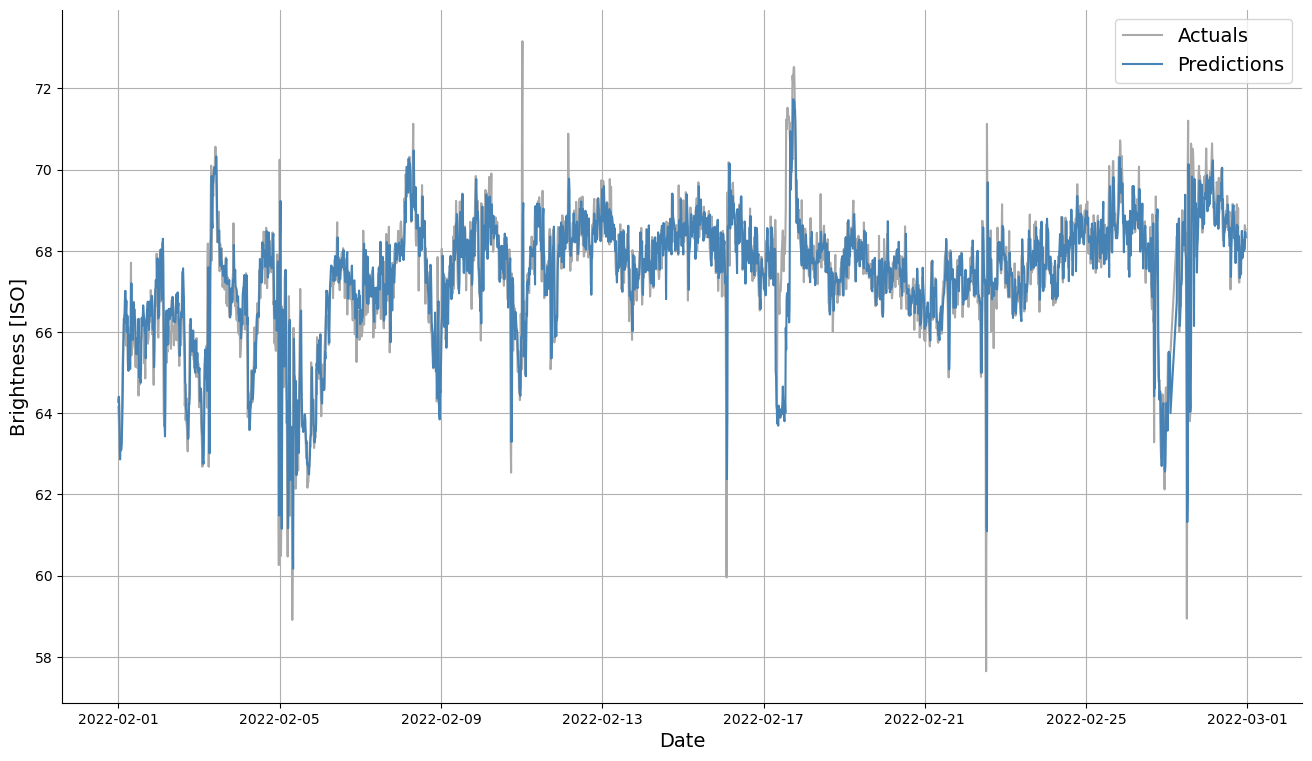

In [131]:
from evaluation import evaluate_model, check_model, create_check_summary
from functions import calculate_shap_values, create_shap_plots, data_correlation, data_cor_names_to_matrix
from sklearn.metrics import r2_score
from sklearn.ensemble import HistGradientBoostingRegressor

monotonic_cst = [0 for _ in range(len(features))]
monotonic_cst[0] = 1

mlflow.set_experiment("Hist_gradient_model")
with mlflow.start_run():
    # Log params
    params = {"features": list(X_train.columns)}
    mlflow.log_params(params) 
    # Train model
    model = HistGradientBoostingRegressor(random_state=400, monotonic_cst=monotonic_cst, l2_regularization=1, learning_rate=0.1, loss='squared_error', max_depth=7, max_features=0.5, max_iter=300, max_leaf_nodes=31, min_samples_leaf=20)
    #model = HistGradientBoostingRegressor(random_state=400, monotonic_cst=monotonic_cst, l2_regularization=1, learning_rate=0.1, loss='squared_error', max_depth=7, max_features=0.5, max_iter=200, max_leaf_nodes=63, min_samples_leaf=20)
    model.fit(X_train[features], y_train)



    # Log evaluation and metrics
    model_metrics, evaluation_plot = evaluate_model(model, X_test[features], y_test)
    check_result = check_model('s1', model, 'GradientBoostingRegressor', X_test[features])
    print(create_check_summary(check_result))
    mlflow.log_metrics(model_metrics)
    mlflow.log_figure(evaluation_plot, artifact_file="Evaluation_Plot/evaluation_plot.png")

    # Log shap values and plots
    shap_values = functions.calculate_shap_values(model=model, model_type='GradientBoostingRegressor', X_calibrate=X_test[features])
    shap_plots = functions.create_shap_plots(shap_values=shap_values, feature_values=X_test[features])
    
    for plot_name, fig in shap_plots.items():
        mlflow.log_figure(fig, artifact_file=f"SHAP_Plots/{plot_name}.png")
    

### Feature importance (mean |SHAP|)

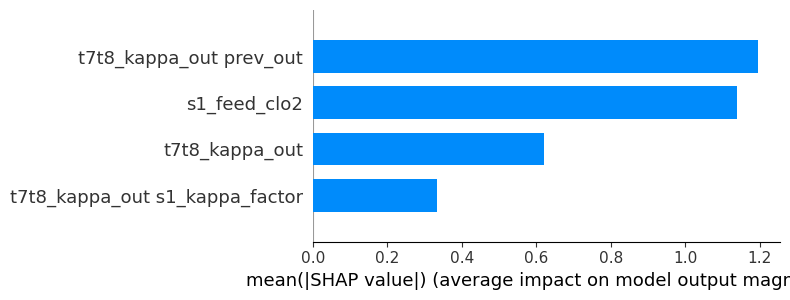

In [133]:
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test[features])
shap.summary_plot(shap_values, X_test[features], plot_type="bar")

### Validation-set metrics

Model metrics
  - explained_variance_score: 0.7135
  - mean_absolute_error: 0.6464
  - mean_absolute_percentage_error: 0.0096
  - mean_bias: -0.1096
  - mean_squared_error: 1.1429
  - median_absolute_error: 0.4214
  - pct_obs_within_pm_1: 0.8337
  - r2_score: 0.7104



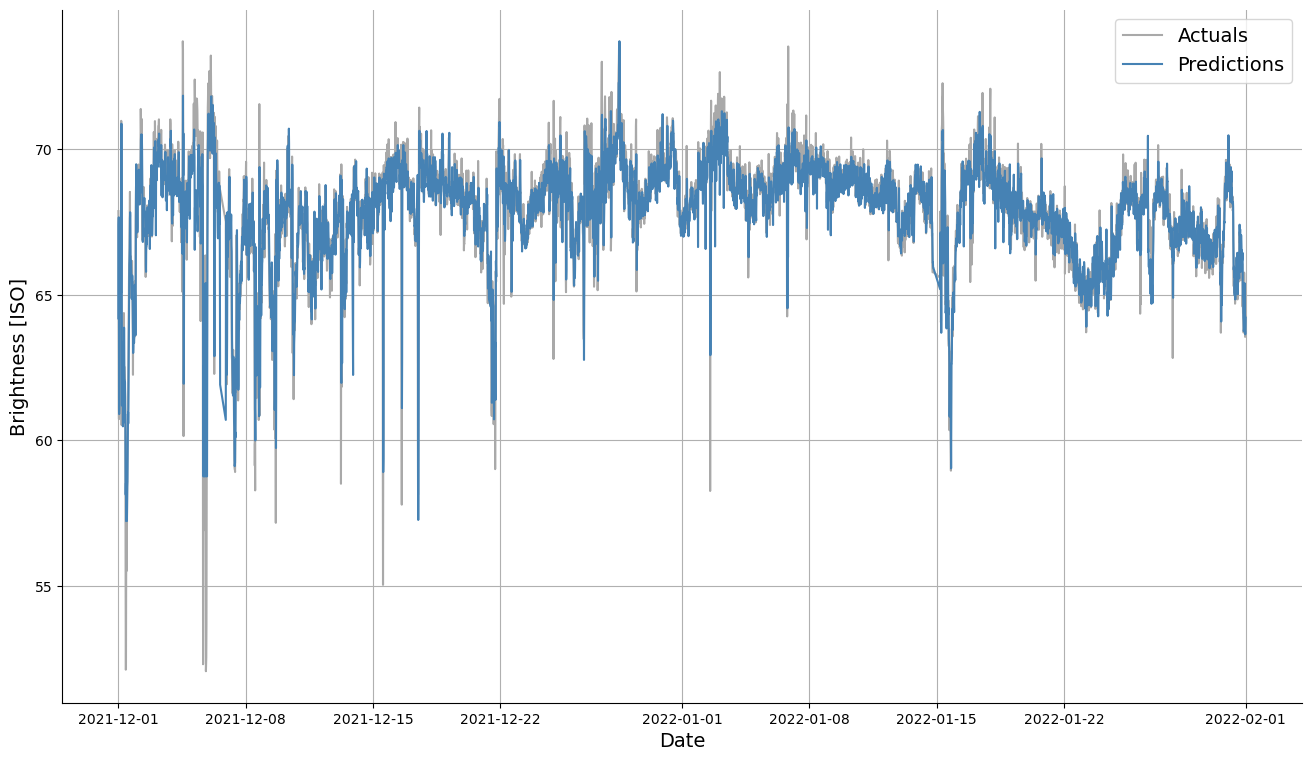

In [128]:
model_metrics, evaluation_plot = evaluate_model(model, X_val[features], y_val)

### Training-set metrics

Model metrics
  - explained_variance_score: 0.912
  - mean_absolute_error: 0.6764
  - mean_absolute_percentage_error: 0.0105
  - mean_bias: 0.0023
  - mean_squared_error: 0.9391
  - median_absolute_error: 0.49
  - pct_obs_within_pm_1: 0.7924
  - r2_score: 0.912



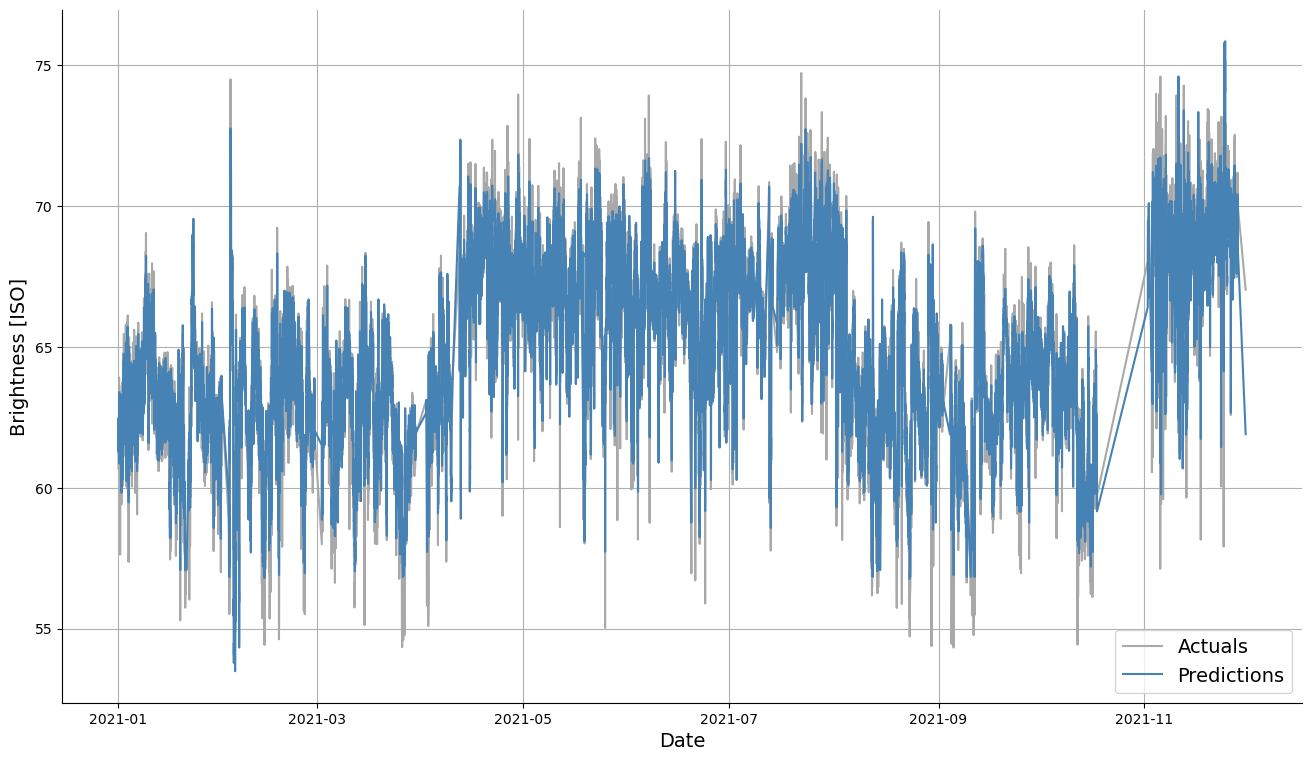

In [129]:
model_metrics, evaluation_plot = evaluate_model(model, X_train[features], y_train)